# Khám Phá và Trực Quan Hóa Dữ Liệu - Phát Hiện Video Độc Hại

Notebook này phân tích và trực quan hóa bộ dữ liệu video độc hại dành cho trẻ em.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Tải Dữ Liệu

In [4]:
# Đọc các file metadata
train_df = pd.read_csv('hf_dataset_merged/metadata_train.csv')
val_df = pd.read_csv('hf_dataset_merged/metadata_val.csv')
test_df = pd.read_csv('hf_dataset_merged/metadata_test.csv')

# Thêm cột để phân biệt dataset
train_df['dataset'] = 'train'
val_df['dataset'] = 'val'
test_df['dataset'] = 'test'

# Kết hợp tất cả dataset
all_data = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Tổng số mẫu: {len(all_data)}")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nXem trước dữ liệu:")
all_data.head(10)

Tổng số mẫu: 2745
Train: 2196 | Val: 274 | Test: 275

Xem trước dữ liệu:


,file_name,label,dataset
0,data/3ecceac8-7583948982750022932.mp4,game,train
1,data/13b788a0-6906117952534367489.mp4,politically_sensitive,train
2,data/e7f0c75a-Download_-_2026-01-10T190943.456...,"sexual_harm,cultural_violation",train
3,data/f54823db-7571406800616951048.mp4,toxic_behavior,train
4,data/a12f3ba1-7584061438008888592.mp4,game_risk_impact,train
5,data/519aa51e-7580588380421983489.mp4,dangerous_acts,train
6,data/56ff5e3c-7566036406443838740.mp4,"normal_content,toxic_behavior",train
7,data/c0fcdd90-7542876942991723794.mp4,politically_sensitive,train
8,data/a0103ec1-Download_43.mp4,graphic_violence,train
9,data/729fcf68-7494812927237590318.mp4,normal_content,train


## 2. Phân Tích Cơ Bản

In [5]:
# Kiểm tra thông tin dataset
print("Thông tin về dataset:")
print(all_data.info())
print("\nKiểm tra giá trị null:")
print(all_data.isnull().sum())

Thông tin về dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2745 entries, 0 to 2744
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   file_name  2745 non-null   str  
 1   label      2745 non-null   str  
 2   dataset    2745 non-null   str  
dtypes: str(3)
memory usage: 64.5 KB
None

Kiểm tra giá trị null:
file_name    0
label        0
dataset      0
dtype: int64


## 3. Xử Lý Multi-Label

Một số video có nhiều nhãn (multi-label), cần tách ra để phân tích

In [6]:
# Tách các nhãn (có thể có nhiều nhãn cách nhau bởi dấu phẩy)
def extract_labels(label_str):
    return [label.strip() for label in str(label_str).split(',')]

# Tạo danh sách tất cả các nhãn
all_labels = []
for label in all_data['label']:
    all_labels.extend(extract_labels(label))

# Đếm số lượng mỗi nhãn
label_counts = Counter(all_labels)
print(f"Tổng số nhãn duy nhất: {len(label_counts)}")
print("\nPhân bố các nhãn:")
for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{label:30s}: {count:4d} ({count/len(all_data)*100:.2f}%)")

Tổng số nhãn duy nhất: 15

Phân bố các nhãn:
normal_content                : 1063 (38.72%)
sexual_harm                   :  291 (10.60%)
cultural_violation            :  203 (7.40%)
graphic_violence              :  199 (7.25%)
dangerous_acts                :  195 (7.10%)
horror_scary                  :  160 (5.83%)
toxic_behavior                :  143 (5.21%)
ai_slop                       :  133 (4.85%)
politically_sensitive         :  127 (4.63%)
educational_history           :  126 (4.59%)
gambling_drugs                :  119 (4.34%)
scam_fraud                    :  106 (3.86%)
game_risk_impact              :  103 (3.75%)
game                          :   79 (2.88%)
self_harm_suicide             :   78 (2.84%)


In [7]:
# Kiểm tra bao nhiêu mẫu có multi-label
multi_label_samples = all_data[all_data['label'].str.contains(',', na=False)]
print(f"Số lượng mẫu có nhiều nhãn: {len(multi_label_samples)} ({len(multi_label_samples)/len(all_data)*100:.2f}%)")
print("\nVí dụ các mẫu multi-label:")
multi_label_samples.head(10)

Số lượng mẫu có nhiều nhãn: 346 (12.60%)

Ví dụ các mẫu multi-label:


,file_name,label,dataset
2,data/e7f0c75a-Download_-_2026-01-10T190943.456...,"sexual_harm,cultural_violation",train
6,data/56ff5e3c-7566036406443838740.mp4,"normal_content,toxic_behavior",train
11,data/517eebc6-7563549208523984148.mp4,"self_harm_suicide,normal_content",train
26,data/bd29a66a-7557236070820220167.mp4,"sexual_harm,normal_content",train
37,data/0fdf8bdb-7572888703165533460.mp4,"scam_fraud,normal_content",train
39,data/83646bda-Download_44.mp4,"ai_slop,sexual_harm",train
68,data/b7c50eba-glambing_42271.mp4,"gambling_drugs,game_risk_impact",train
76,data/3391097b-7461580178611834130.mp4,"sexual_harm,normal_content",train
89,data/57fb7f38-7565816054182628615.mp4,"normal_content,toxic_behavior",train
97,data/d9cc5ab4-7439399793664773394.mp4,"sexual_harm,cultural_violation",train


## 4. Trực Quan Hóa Phân Bố Nhãn

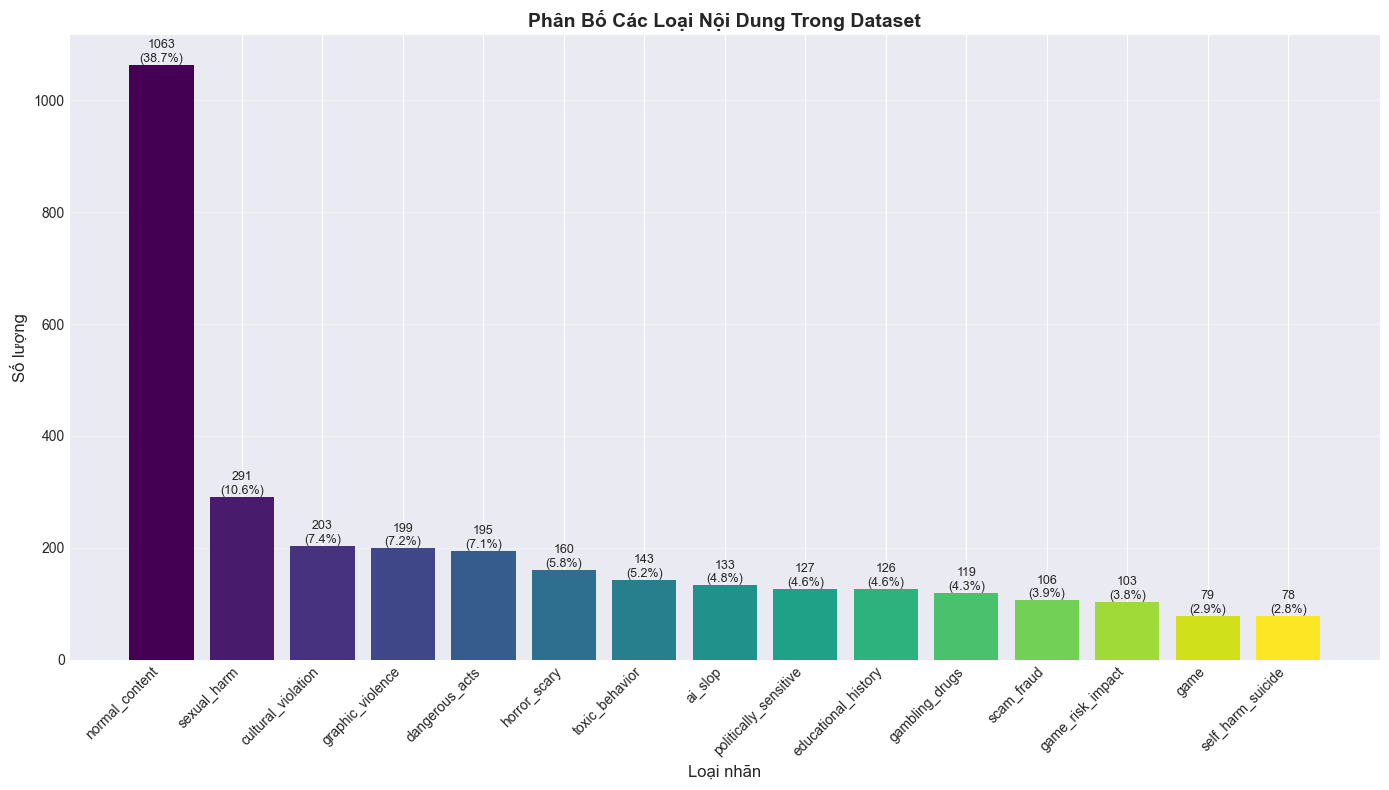

In [8]:
# Biểu đồ cột - Phân bố các nhãn
fig, ax = plt.subplots(figsize=(14, 8))
labels_sorted = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
labels = [l[0] for l in labels_sorted]
counts = [l[1] for l in labels_sorted]

bars = ax.bar(range(len(labels)), counts, color=plt.cm.viridis(np.linspace(0, 1, len(labels))))
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Số lượng', fontsize=12)
ax.set_xlabel('Loại nhãn', fontsize=12)
ax.set_title('Phân Bố Các Loại Nội Dung Trong Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Thêm số liệu lên mỗi cột
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(all_data)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

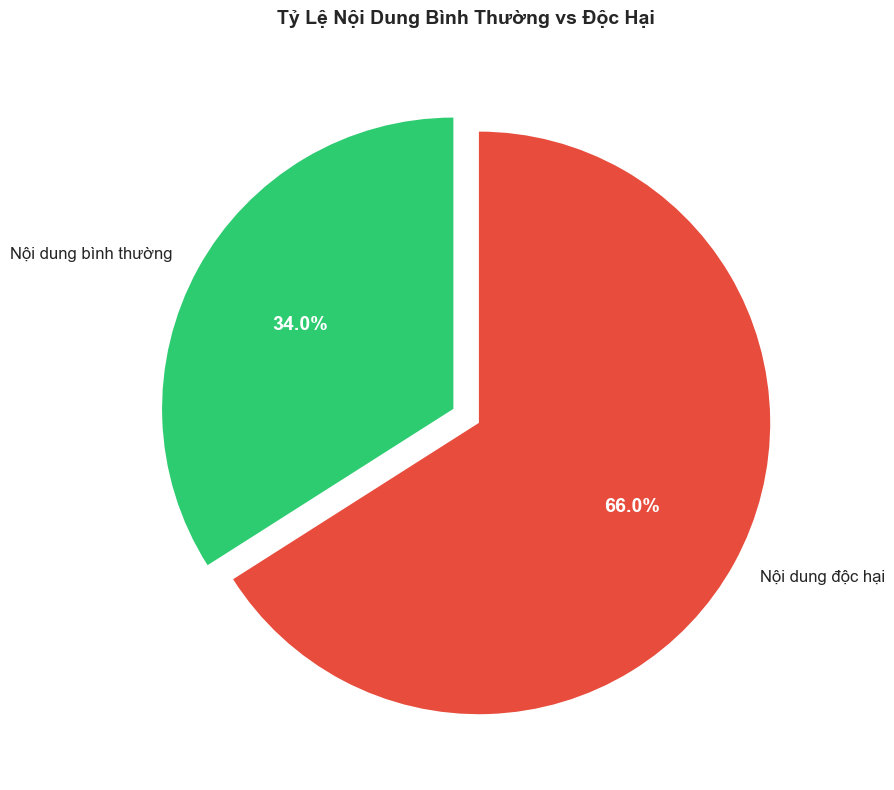

Nội dung bình thường: 1063 (34.02%)
Nội dung độc hại: 2062 (65.98%)


In [9]:
# Biểu đồ tròn - Tỷ lệ nội dung normal vs harmful
normal_count = label_counts.get('normal_content', 0)
harmful_count = sum(count for label, count in label_counts.items() if label != 'normal_content')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
wedges, texts, autotexts = ax.pie([normal_count, harmful_count], 
                                    labels=['Nội dung bình thường', 'Nội dung độc hại'],
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    explode=explode,
                                    textprops={'fontsize': 12})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax.set_title('Tỷ Lệ Nội Dung Bình Thường vs Độc Hại', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"Nội dung bình thường: {normal_count} ({normal_count/(normal_count+harmful_count)*100:.2f}%)")
print(f"Nội dung độc hại: {harmful_count} ({harmful_count/(normal_count+harmful_count)*100:.2f}%)")

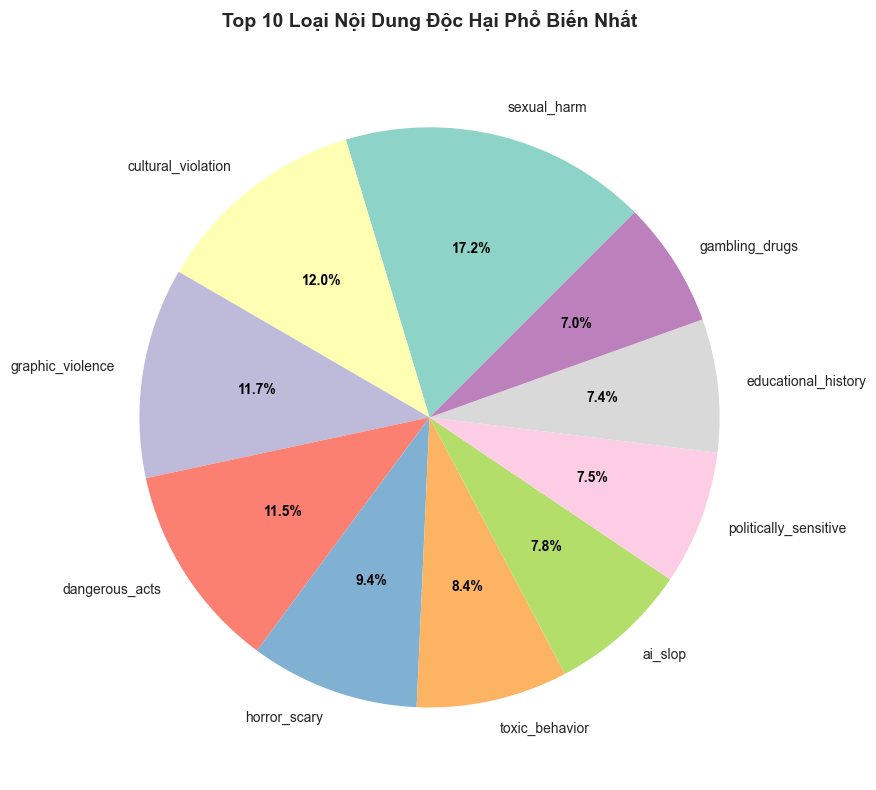

In [10]:
# Biểu đồ tròn - Top 10 loại nội dung độc hại
harmful_labels = {k: v for k, v in label_counts.items() if k != 'normal_content'}
top_10_harmful = dict(sorted(harmful_labels.items(), key=lambda x: x[1], reverse=True)[:10])

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.Set3(range(len(top_10_harmful)))
wedges, texts, autotexts = ax.pie(top_10_harmful.values(),
                                    labels=top_10_harmful.keys(),
                                    autopct='%1.1f%%',
                                    startangle=45,
                                    colors=colors,
                                    textprops={'fontsize': 10})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

ax.set_title('Top 10 Loại Nội Dung Độc Hại Phổ Biến Nhất', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 5. Phân Tích Theo Dataset (Train/Val/Test)

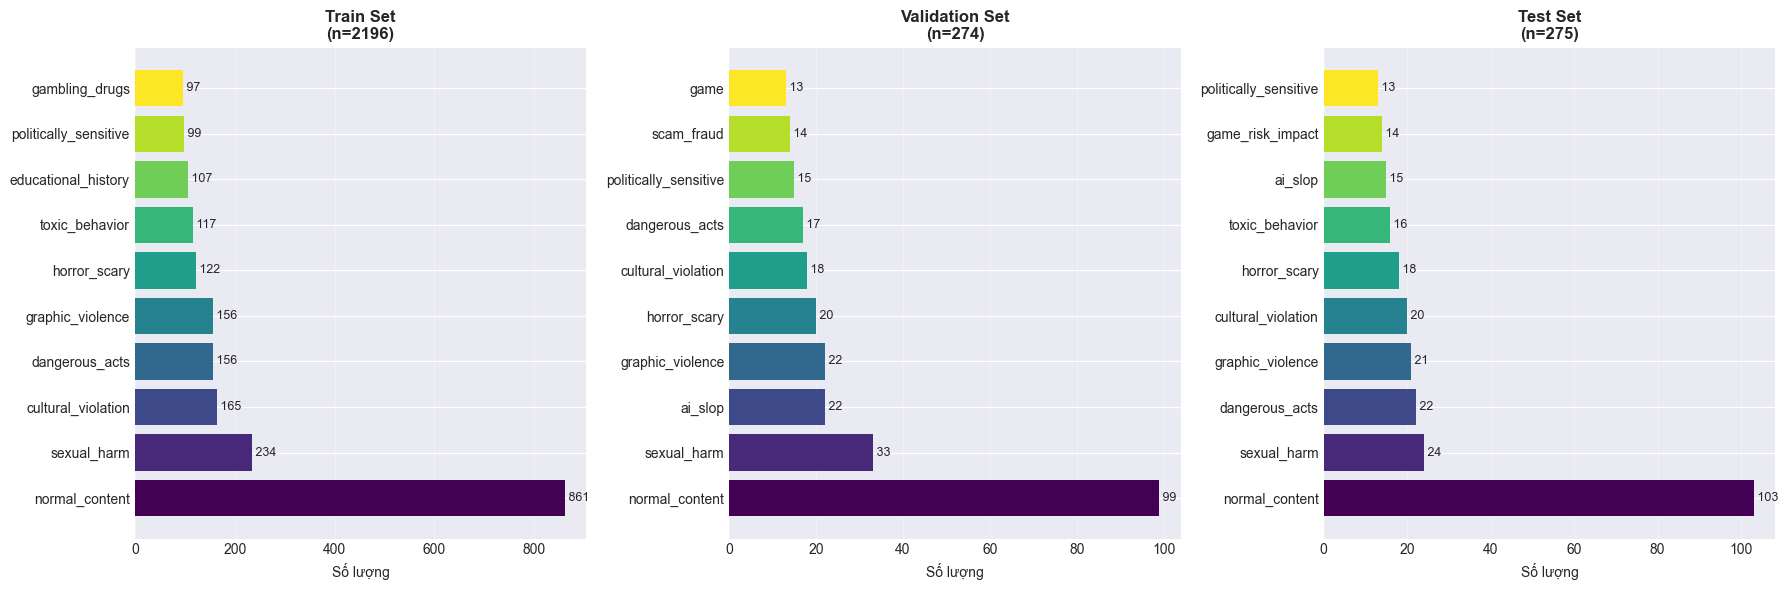

In [11]:
# So sánh phân bố giữa train, val, test
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (dataset_name, df) in enumerate([('Train', train_df), ('Validation', val_df), ('Test', test_df)]):
    labels_list = []
    for label in df['label']:
        labels_list.extend(extract_labels(label))
    
    label_counts_subset = Counter(labels_list)
    labels_sorted = sorted(label_counts_subset.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [l[0] for l in labels_sorted]
    counts = [l[1] for l in labels_sorted]
    
    axes[idx].barh(labels, counts, color=plt.cm.viridis(np.linspace(0, 1, len(labels))))
    axes[idx].set_xlabel('Số lượng', fontsize=10)
    axes[idx].set_title(f'{dataset_name} Set\n(n={len(df)})', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    
    for i, count in enumerate(counts):
        axes[idx].text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Phân Tích Multi-Label

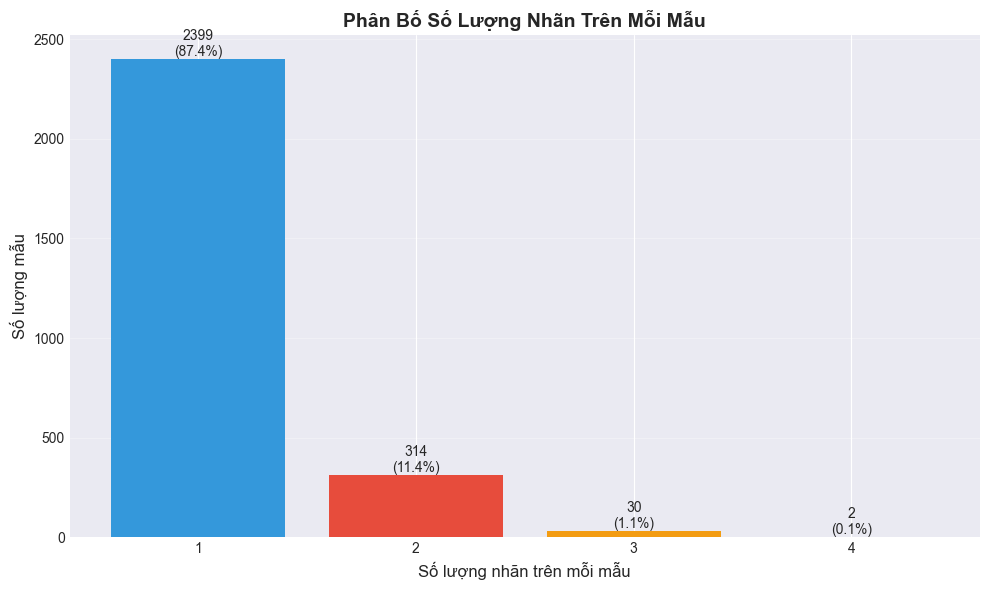


Thống kê số nhãn trên mỗi mẫu:
count    2745.000000
mean        1.138434
std         0.381513
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: label, dtype: float64


In [12]:
# Phân bố số lượng nhãn trên mỗi mẫu
labels_per_sample = all_data['label'].apply(lambda x: len(extract_labels(x)))

fig, ax = plt.subplots(figsize=(10, 6))
label_count_dist = labels_per_sample.value_counts().sort_index()
bars = ax.bar(label_count_dist.index, label_count_dist.values, 
              color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
ax.set_xlabel('Số lượng nhãn trên mỗi mẫu', fontsize=12)
ax.set_ylabel('Số lượng mẫu', fontsize=12)
ax.set_title('Phân Bố Số Lượng Nhãn Trên Mỗi Mẫu', fontsize=14, fontweight='bold')
ax.set_xticks(label_count_dist.index)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(all_data)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nThống kê số nhãn trên mỗi mẫu:")
print(labels_per_sample.describe())

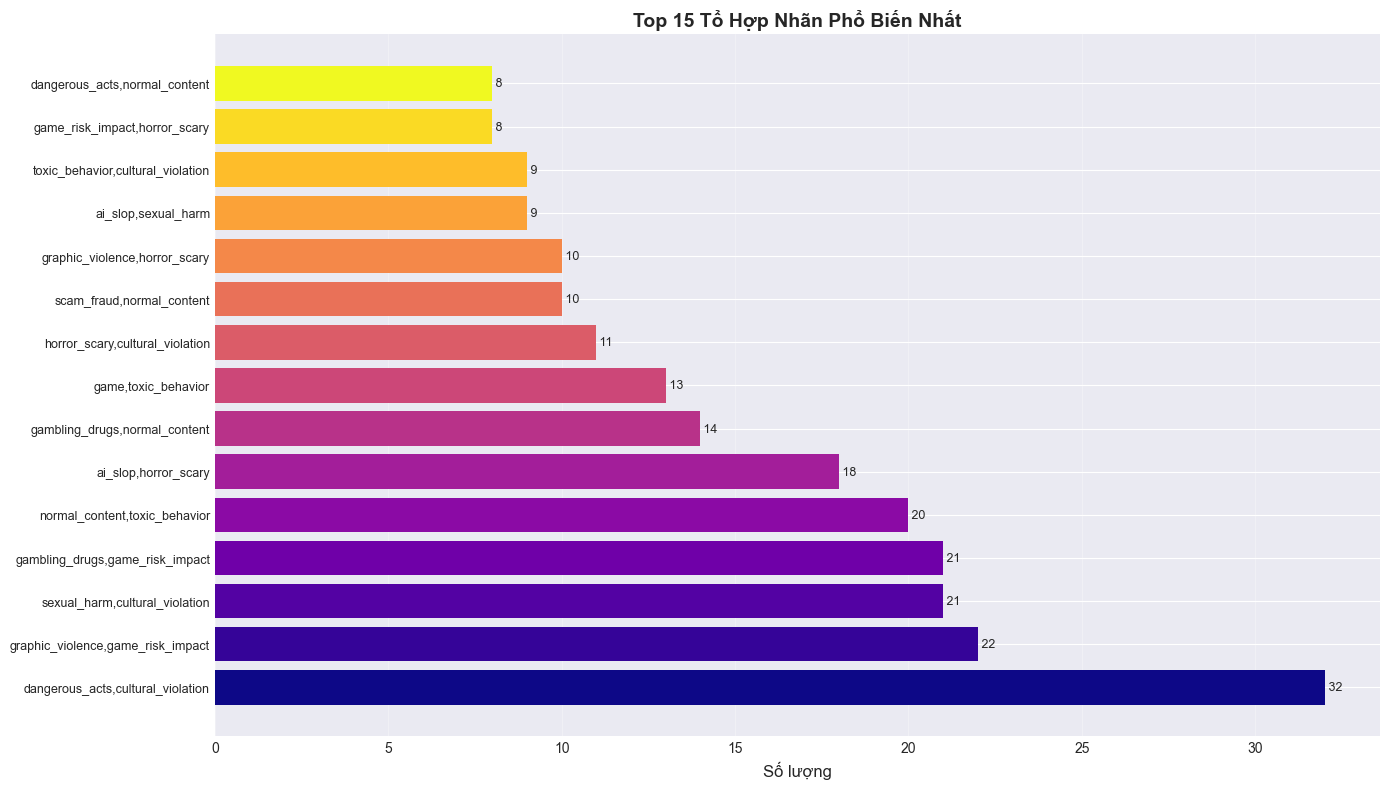

In [13]:
# Top các tổ hợp nhãn phổ biến nhất (cho multi-label)
multi_label_combos = multi_label_samples['label'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.arange(len(multi_label_combos))
bars = ax.barh(y_pos, multi_label_combos.values, color=plt.cm.plasma(np.linspace(0, 1, len(multi_label_combos))))
ax.set_yticks(y_pos)
ax.set_yticklabels([label[:50] + '...' if len(label) > 50 else label for label in multi_label_combos.index], fontsize=9)
ax.set_xlabel('Số lượng', fontsize=12)
ax.set_title('Top 15 Tổ Hợp Nhãn Phổ Biến Nhất', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, count in enumerate(multi_label_combos.values):
    ax.text(count, i, f' {count}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Ma Trận Đồng Xuất Hiện (Co-occurrence Matrix)

Phân tích các nhãn thường xuất hiện cùng nhau

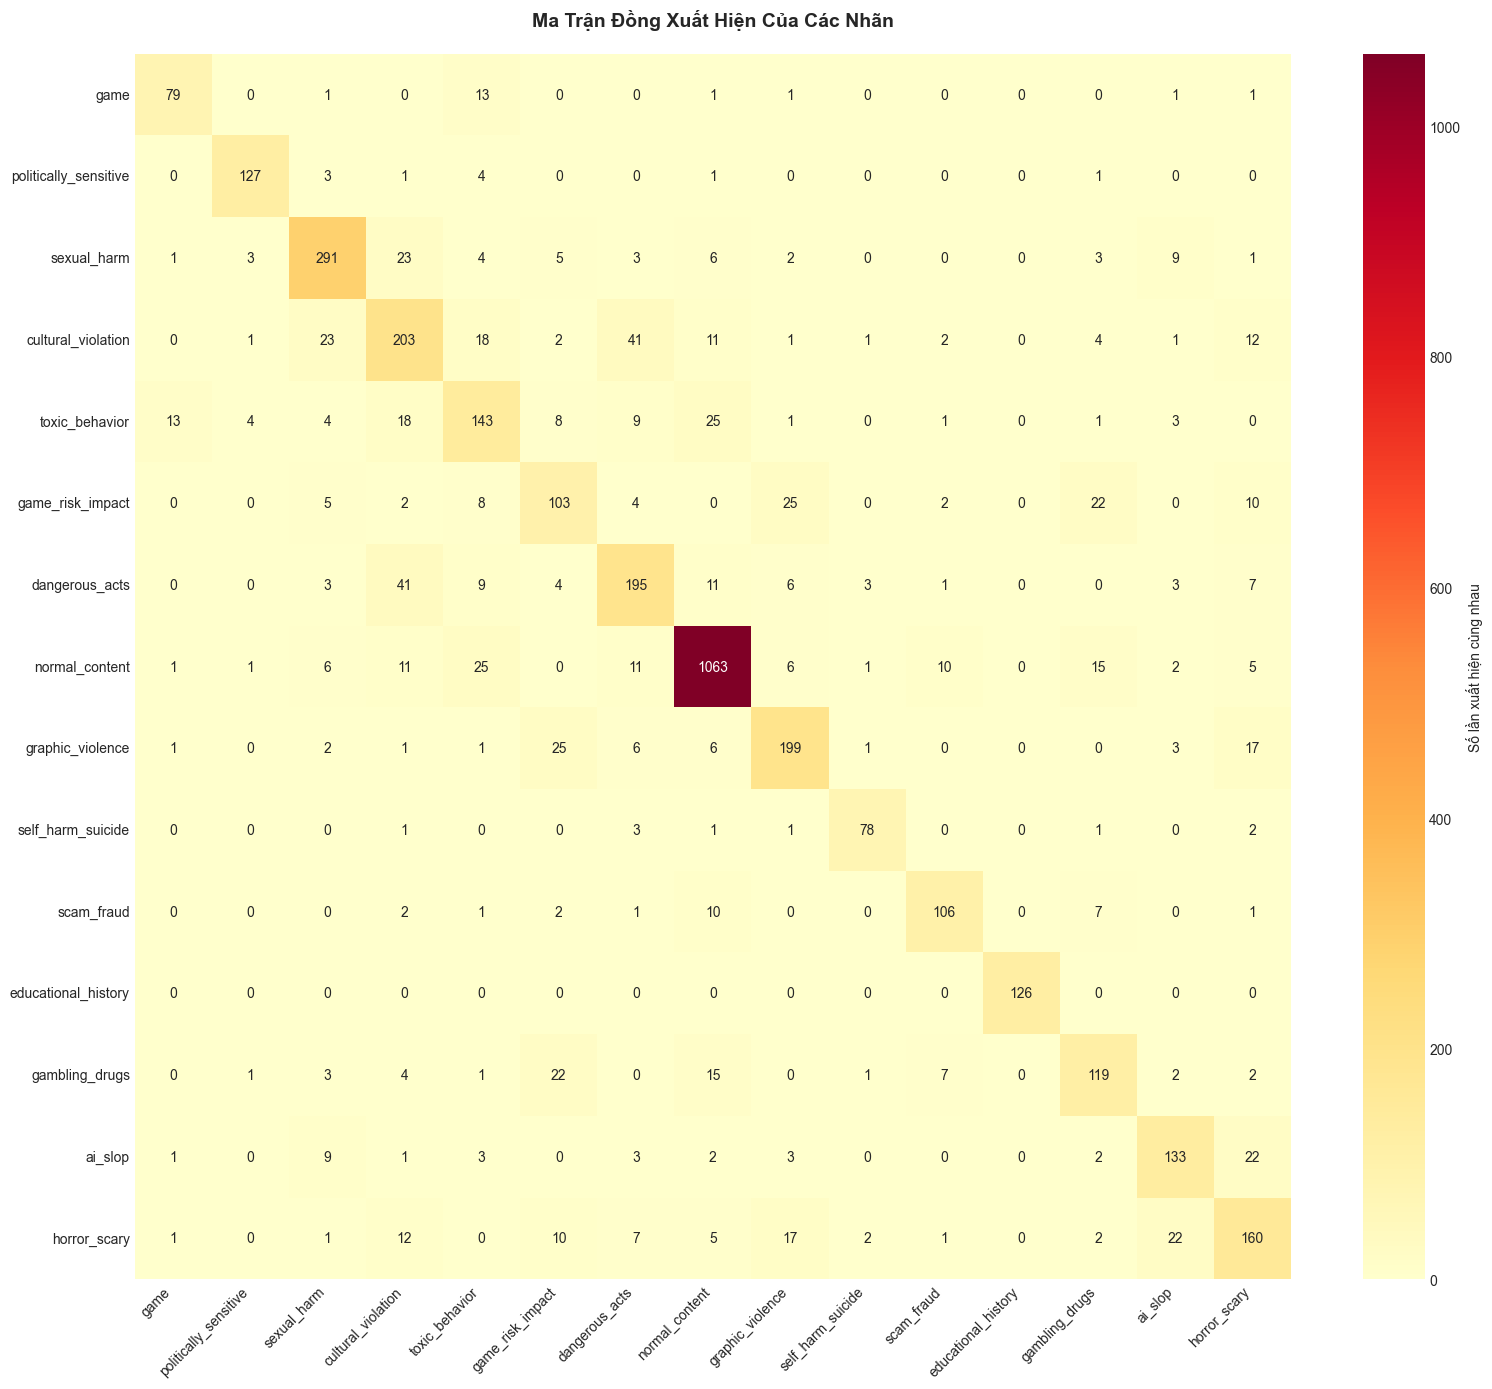

In [14]:
# Tạo ma trận đồng xuất hiện
unique_labels = list(label_counts.keys())
n_labels = len(unique_labels)
cooccurrence_matrix = np.zeros((n_labels, n_labels))

for label_str in all_data['label']:
    labels = extract_labels(label_str)
    for i, label1 in enumerate(unique_labels):
        for j, label2 in enumerate(unique_labels):
            if label1 in labels and label2 in labels:
                cooccurrence_matrix[i, j] += 1

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cooccurrence_matrix, 
            xticklabels=unique_labels, 
            yticklabels=unique_labels,
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Số lần xuất hiện cùng nhau'},
            ax=ax)
ax.set_title('Ma Trận Đồng Xuất Hiện Của Các Nhãn', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Tóm Tắt Thống Kê

In [15]:
print("="*80)
print("TÓM TẮT THỐNG KÊ BỘ DỮ LIỆU PHÁT HIỆN VIDEO ĐỘC HẠI")
print("="*80)
print(f"\n1. TỔNG QUAN:")
print(f"   - Tổng số video: {len(all_data)}")
print(f"   - Train: {len(train_df)} ({len(train_df)/len(all_data)*100:.1f}%)")
print(f"   - Validation: {len(val_df)} ({len(val_df)/len(all_data)*100:.1f}%)")
print(f"   - Test: {len(test_df)} ({len(test_df)/len(all_data)*100:.1f}%)")

print(f"\n2. PHÂN BỐ NHÃN:")
print(f"   - Số loại nhãn duy nhất: {len(label_counts)}")
print(f"   - Nội dung bình thường: {normal_count} ({normal_count/len(all_data)*100:.1f}%)")
print(f"   - Nội dung độc hại: {len(all_data) - normal_count} ({(len(all_data) - normal_count)/len(all_data)*100:.1f}%)")

print(f"\n3. MULTI-LABEL:")
print(f"   - Số mẫu có nhiều nhãn: {len(multi_label_samples)} ({len(multi_label_samples)/len(all_data)*100:.1f}%)")
print(f"   - Số nhãn trung bình/mẫu: {labels_per_sample.mean():.2f}")
print(f"   - Số nhãn tối đa/mẫu: {labels_per_sample.max()}")

print(f"\n4. TOP 5 LOẠI NỘI DUNG ĐỘC HẠI:")
top_5_harmful = sorted(harmful_labels.items(), key=lambda x: x[1], reverse=True)[:5]
for i, (label, count) in enumerate(top_5_harmful, 1):
    print(f"   {i}. {label}: {count} ({count/sum(harmful_labels.values())*100:.1f}% của nội dung độc hại)")

print("\n" + "="*80)

TÓM TẮT THỐNG KÊ BỘ DỮ LIỆU PHÁT HIỆN VIDEO ĐỘC HẠI

1. TỔNG QUAN:
   - Tổng số video: 2745
   - Train: 2196 (80.0%)
   - Validation: 274 (10.0%)
   - Test: 275 (10.0%)

2. PHÂN BỐ NHÃN:
   - Số loại nhãn duy nhất: 15
   - Nội dung bình thường: 1063 (38.7%)
   - Nội dung độc hại: 1682 (61.3%)

3. MULTI-LABEL:
   - Số mẫu có nhiều nhãn: 346 (12.6%)
   - Số nhãn trung bình/mẫu: 1.14
   - Số nhãn tối đa/mẫu: 4

4. TOP 5 LOẠI NỘI DUNG ĐỘC HẠI:
   1. sexual_harm: 291 (14.1% của nội dung độc hại)
   2. cultural_violation: 203 (9.8% của nội dung độc hại)
   3. graphic_violence: 199 (9.7% của nội dung độc hại)
   4. dangerous_acts: 195 (9.5% của nội dung độc hại)
   5. horror_scary: 160 (7.8% của nội dung độc hại)



## 9. Xuất Thống Kê Chi Tiết

In [16]:
# Tạo DataFrame thống kê chi tiết
stats_df = pd.DataFrame([
    {'Label': label, 'Count': count, 'Percentage': f"{count/len(all_data)*100:.2f}%"}
    for label, count in sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
])

print("\nBảng thống kê chi tiết:")
stats_df


Bảng thống kê chi tiết:


,Label,Count,Percentage
0,normal_content,1063,38.72%
1,sexual_harm,291,10.60%
2,cultural_violation,203,7.40%
3,graphic_violence,199,7.25%
4,dangerous_acts,195,7.10%
5,horror_scary,160,5.83%
6,toxic_behavior,143,5.21%
7,ai_slop,133,4.85%
8,politically_sensitive,127,4.63%
9,educational_history,126,4.59%


In [17]:
# Lưu thống kê ra file CSV
stats_df.to_csv('label_statistics.csv', index=False, encoding='utf-8-sig')
print("✓ Đã lưu thống kê vào file 'label_statistics.csv'")

✓ Đã lưu thống kê vào file 'label_statistics.csv'
